# Purpose:
- To QC GLM and coding score calculation process.
- Curate activity and GLM fit information per cell and print them out as png for easy flipping.
# Contents:
- Mean response to images, changes, omissions
- Correlation with running and pupil (full activity trace on top of running and pupil dynamics)
    - Both dff and events
- GLM fit kernels (images, changes, omissions, hits, misses, running, pupil, licks)
- GLM model performance and coding scores
    - Full VE, adj full VE and adj model VE for each drop-out model and for each single model
    - Look at the effect of drop-out, from window where VE was the highest (top), middle(median), low (20th percentile) and where drop-out score was the highest, middle, and low.
        - For all-images, omissions (if there is), tasks, behavior
        - Also hit, miss, running, pupil, licks

In [1]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from sklearn.decomposition import PCA
import umap
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from scipy.cluster.hierarchy import fcluster
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objs as go

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



/opt/conda/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [3]:
# GLM parameters
dm_version = 2
data_type = 'events'
suffix = ''

# Loading session information
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)


session_ind_name_dict = {6: 'Familiar',
                         7: 'Novel',
                         8: 'Novel+1'}

# ROICat
roicat_df_fn = '/root/capsule/scratch/Thyme/roicat_df.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)
fnn_session_inds = [6, 7, 8]
fnn_roi_df = roicat_df.query('valid_roi and (session_ind in @fnn_session_inds) and matched')
fnn_uc_series = fnn_roi_df.groupby('unique_cell_name').size()
fnn_matched_uc = fnn_uc_series.index.values[np.where(fnn_uc_series==len(fnn_session_inds))[0]]
print(len(fnn_matched_uc))
fnn_all_matched_roi_df = fnn_roi_df.query('unique_cell_name in @fnn_matched_uc')
assert fnn_all_matched_roi_df.valid_roi.all()

# normalized coding scores
feature_table_fn = f'/root/capsule/scratch/Thyme/clustering/feature_table_fnn_dm_v{dm_version:02}.pkl'
feature_table = pd.read_pickle(feature_table_fn)

feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

# mean response folder
mean_response_dir = Path('/root/capsule/scratch/Thyme/responses_condition_v1')


# One example cell

In [27]:
session_response_df['timestamps'].values[0]

array([-3.        , -2.90691729, -2.81383457, -2.72075186, -2.62766915,
       -2.53458644, -2.44150372, -2.34842101, -2.2553383 , -2.16225558,
       -2.06917287, -1.97609016, -1.88300744, -1.78992473, -1.69684202,
       -1.60375931, -1.51067659, -1.41759388, -1.32451117, -1.23142845,
       -1.13834574, -1.04526303, -0.95218032, -0.8590976 , -0.76601489,
       -0.67293218, -0.57984946, -0.48676675, -0.39368404, -0.30060133,
       -0.20751861, -0.1144359 , -0.02135319,  0.07172953,  0.16481224,
        0.25789495,  0.35097767,  0.44406038,  0.53714309,  0.6302258 ,
        0.72330852,  0.81639123,  0.90947394,  1.00255666,  1.09563937,
        1.18872208,  1.28180479,  1.37488751,  1.46797022,  1.56105293,
        1.65413565,  1.74721836,  1.84030107,  1.93338378,  2.0264665 ,
        2.11954921,  2.21263192,  2.30571464,  2.39879735,  2.49188006,
        2.58496278,  2.67804549,  2.7711282 ,  2.86421091,  2.95729363])

In [56]:
# session
session_ind = 6
session_name = session_info_df.query(f'session_ind=={session_ind}').session_name.values[0]

# Mean responses
mean_response_fn = mean_response_dir / f'response_v1_{session_name}.feather'
mean_session_response_df = pd.read_feather(mean_response_fn).reset_index(drop=False).rename(columns={'cell_roi_id': 'session_roi_index'})
session_response_df['session_roi_id'] = session_response_df.apply(lambda x: f'{x.session_key}_{x.plane_name}_{x.session_roi_index:04}',
                                                                      axis=1)
def _assign_condition_name(x):
    if 'image' in x:
        return 'image'
    elif 'change' in x:
        return 'change'
    elif 'omit' in x:
        return 'omission'
    else:
        raise ValueError('Invalid condition')
session_response_df['condition_name'] = session_response_df.condition.apply(lambda x: _assign_condition_name(x))

session_roi_ids = np.sort(session_response_df.session_roi_id.unique())

# Add # of flashes to get sem instead of std.
# From BOD
# 

# GLM results
glm_fn = Path(glm_dir) / f'glm_results_v{dm_version:02}_{session_name}_{data_type}{suffix}.npy'
glm_results = np.load(glm_fn, allow_pickle=True).item()

X, response, response_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_name, data_type, dm_version, load_path=glm_dir)


# cell
cell_i = 0
session_roi_id = session_roi_ids[cell_i]

# mean responses
cell_response_df = session_response_df.query(f'session_roi_id=="{session_roi_id}"')
    



In [49]:
session_response_df.condition.unique()[0]

"image_name in ['im065', 'im069', 'im063', 'im066', 'im077', 'im062', 'im061', 'im085'] and flashes_since_change>3 and flashes_since_omission > flashes_since_change"

In [54]:
stim_table

,stimulus_block,image_index,image_name,movie_frame_index,duration,start_time,stop_time,start_frame,end_frame,is_change,omitted,movie_repeat,flashes_since_change,stimulus_name,image_set,flashes_since_omission
stimulus_presentations_id,,,,,,,,,,,,,,,,
0,0,-99,NaN,-99,321.72721,0.00000,321.72721,0,17985,<NA>,<NA>,-99,-99,spontaneous,NaN,1
1,1,0,im000,-99,0.24987,321.72721,321.97708,17985,18000,False,False,-99,0,Natural_Images_Lum_Matched_set_ophys_6_2017,Natural_Images_Lum_Matched_set_ophys_6_2017.07.14,2
2,1,0,im000,-99,0.25020,322.47734,322.72754,18030,18045,False,False,-99,1,Natural_Images_Lum_Matched_set_ophys_6_2017,Natural_Images_Lum_Matched_set_ophys_6_2017.07.14,3
3,1,0,im000,-99,0.25019,323.22799,323.47818,18075,18090,False,False,-99,2,Natural_Images_Lum_Matched_set_ophys_6_2017,Natural_Images_Lum_Matched_set_ophys_6_2017.07.14,4
4,1,0,im000,-99,0.24983,323.97899,324.22882,18120,18135,False,False,-99,3,Natural_Images_Lum_Matched_set_ophys_6_2017,Natural_Images_Lum_Matched_set_ophys_6_2017.07.14,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13798,3,-99,NaN,895,0.03332,4525.79961,4525.83293,270019,270020,<NA>,<NA>,9,-99,natural_movie_one,NaN,9010
13799,3,-99,NaN,896,0.03340,4525.83293,4525.86633,270021,270022,<NA>,<NA>,9,-99,natural_movie_one,NaN,9011
13800,3,-99,NaN,897,0.03332,4525.86633,4525.89965,270023,270024,<NA>,<NA>,9,-99,natural_movie_one,NaN,9012


In [55]:
session_response_df.condition.unique()[0]

"image_name in ['im065', 'im069', 'im063', 'im066', 'im077', 'im062', 'im061', 'im085'] and flashes_since_change>3 and flashes_since_omission > flashes_since_change"

In [60]:
raw_path = data_dir / session_name
processed_path = list(data_dir.glob(f'{session_name}_processed*'))[0]

for plane_folder in processed_path.glob("*"):
    if plane_folder.is_dir() and not plane_folder.stem.startswith("nextflow") \
        and not ('nwb' in plane_folder.stem):
        opid = plane_folder.stem
        break
bod = load_data.load_plane_data(session_name, opid=opid)
stim_table = bod.stimulus_presentations

/comb/src/comb/processing/stimulus/stimulus_processing.py:802: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_change = is_change.fillna(False)
/comb/src/comb/processing/stimulus/presentations.py:514: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  omitted = df["omitted"].fillna(False)


In [61]:
def add_flashes_since_omission(stim_table):
    omitted_ids = np.array([stim_table.index.values[0]-1, *stim_table.query('image_name=="omitted"').index.values])
    def _get_flashes_after(i, ids):
        ids = np.asarray(ids)
        diff = i - ids
        diff = diff[diff>=0]
        return int(np.min(diff))
    flashes_since_omission = stim_table.reset_index(drop=False).stimulus_presentations_id.apply(lambda x: _get_flashes_after(x, omitted_ids)).values
    stim_table['flashes_since_omission'] = flashes_since_omission

add_flashes_since_omission(stim_table)

In [64]:
stim_table.query(session_response_df.condition.unique()[0]).shape[0]

2070

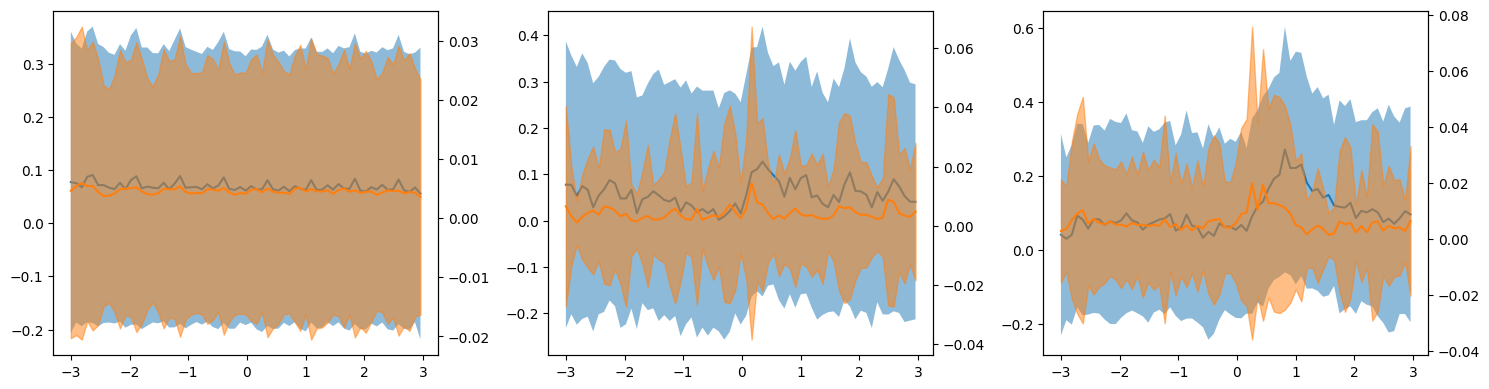

In [43]:
conditions = ['image', 'change', 'omission']
timestamps = cell_response_df.timestamps.values[0]
assert np.all([np.array_equal(t, timestamps) for t in cell_response_df.timestamps.values])
fig, ax = plt.subplots(1, 3, figsize=(15,4))
for i, condition in enumerate(conditions):
    # first, dff
    row = cell_response_df.query(f'condition_name=="{condition}" and data_type=="dff"').iloc[0]
    ax[i].fill_between(timestamps, row.mean_trace + row.std_trace, row.mean_trace - row.std_trace,
                       alpha=0.5)
    ax[i].plot(timestamps, row.mean_trace)
    # then, events
    row = cell_response_df.query(f'condition_name=="{condition}" and data_type=="events"').iloc[0]
    axx = ax[i].twinx()
    axx.fill_between(timestamps, row.mean_trace + row.std_trace, row.mean_trace - row.std_trace,
                     color='C1', alpha=0.5)
    axx.plot(timestamps, row.mean_trace, color='C1')
fig.tight_layout()

## Model examples
- Changes and omissions, separately
    - Based on largest variances
- Pick time windows based on local variance